# Arcing-first probability under random Gaussian tilt

This notebook implements a **gap-based arcing model** and a **Monte Carlo validator**.

For each pad pair,

$G_i = g_0 + d_i - (R_{t,i}+R_{b,i})$

A pad is the arcing-first pad iff its gap is the global minimum and lies in the arcing window:

$0 < G_i < g_{\mathrm{arc}}$.

The notebook provides:

- exact fixed-tilt arcing heatmap
- average analytical heatmap under random Gaussian tilt
- Monte Carlo heatmap by random sampling of dishing and tilt angles
- direct analytical vs Monte Carlo comparison


In [7]:
#!/usr/bin/env python3
"""
Arcing first-event probability under random Gaussian tilt.

Physical model
--------------
Let
    H_i = R_{t,i} + R_{b,i}
    G_i = g0 + d_i - H_i

where
    R_{t,i} ~ N(mu_t, sigma_t^2),
    R_{b,i} ~ N(mu_b, sigma_b^2),
    d_i      = deterministic tilt-induced gap contribution at pad i,
    g0       = optional common nominal gap offset.

Interpretation:
    G_i is the instantaneous pad-to-pad gap.
    Smaller G_i means the pad pair is closer.

Arcing-first event
------------------
For arcing ESD (not first-contact ESD), a pad is eligible only when the gap is positive.
Optionally, arcing is restricted to a finite gap window:

    0 < G_i < g_arc

where g_arc is an arcing threshold in nm. If g_arc is None, the upper bound is removed.

Pad i is the arcing-first pad iff
    0 < G_i < g_arc
and
    G_i < G_j for all j != i.

Thus for fixed tilt, under independence across pad locations,

    P_i^arc = ∫_0^{g_arc} f_i(g) ∏_{j != i} P(G_j > g) dg
            = ∫_0^{g_arc} f_i(g) ∏_{j != i} [1 - F_j(g)] dg,

where G_i ~ N(m_i, sigma^2), with
    m_i = g0 + d_i - (mu_t + mu_b)
    sigma^2 = sigma_t^2 + sigma_b^2

This implementation evaluates the full heatmap in O(QN) time by:
  - computing total_log_survival(g) = Σ_j log P(G_j > g)
  - assembling every pad's integrand from total_log_survival(g) - log P(G_i > g)

Random tilt
-----------
Now assume
    theta_x ~ N(mean_theta_x, sigma_theta_x^2)
    theta_y ~ N(mean_theta_y, sigma_theta_y^2),
independent.

Then the average unconditional heatmap is
    E_theta[P_i^arc(theta)]

and the average conditional heatmap given that arcing occurs is
    E_theta[P_i^arc(theta)] / E_theta[P_arc(theta)],
where
    P_arc(theta) = P(0 < min_j G_j < g_arc).

We evaluate the outer expectation over (theta_x, theta_y) using 2D Gauss-Hermite quadrature.

Monte Carlo
-----------
A Monte Carlo simulator is also provided. It samples:
  - random tilt angles from their Gaussian distributions
  - random top/bottom dishing (or directly their Gaussian sum)
and records which pad has the minimum gap when the minimum gap lies in the arcing window.

This allows direct comparison between:
  1) analytical average heatmap
  2) Monte Carlo estimated average heatmap
"""

from __future__ import annotations

from dataclasses import dataclass, replace
import math
import time
from typing import List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from numpy.polynomial.hermite import hermgauss
from scipy.special import log_ndtr


Array2D = np.ndarray


@dataclass
class Params:
    # Geometry
    die_size_x_mm: float = 2.0
    die_size_y_mm: float = 2.0
    pitch_um: float = 20.0

    # Fixed tilt (used only for fixed-tilt calls)
    theta_x_deg: float = 0.0
    theta_y_deg: float = 0.0

    # Dishing / height distributions
    mu_b_nm: float = 0.0
    sigma_b_nm: float = 1.0
    mu_t_nm: float = 0.0
    sigma_t_nm: float = 1.0

    # Common nominal gap offset
    global_gap_nm: float = 10.0

    # Arcing window: 0 < gap < g_arc_nm
    # Set to None to remove the upper bound.
    g_arc_nm: Optional[float] = 20.0

    # Inner quadrature for fixed-tilt exact map
    quadrature_points: int = 64
    tail_sigma: float = 8.0
    chunk_size: int = 100000
    renormalize_to_arc_probability: bool = True

    # Outer random tilt distribution
    mean_theta_x_deg: float = 0.0
    mean_theta_y_deg: float = 0.0
    sigma_theta_x_deg: float = 1.0e-4
    sigma_theta_y_deg: float = 2.0e-4
    outer_qx: int = 5
    outer_qy: int = 5

    # Monte Carlo
    mc_trials: int = 500
    mc_batch_size: int = 4
    mc_seed: int = 0
    # If True, sample H = R_t + R_b directly from the summed Gaussian.
    # If False, sample R_t and R_b separately and add them.
    sample_sum_directly: bool = True

    # Plotting / saving
    show_plots: bool = True
    save_prefix: str = "arcing_first_event_random_tilt"
    max_plot_pixels: int = 1200

    def validate(self) -> None:
        if self.die_size_x_mm <= 0 or self.die_size_y_mm <= 0:
            raise ValueError("Die sizes must be positive.")
        if self.pitch_um <= 0:
            raise ValueError("Pitch must be positive.")
        if self.sigma_b_nm < 0 or self.sigma_t_nm < 0:
            raise ValueError("Standard deviations must be nonnegative.")
        if self.quadrature_points <= 0:
            raise ValueError("quadrature_points must be positive.")
        if self.tail_sigma <= 0:
            raise ValueError("tail_sigma must be positive.")
        if self.chunk_size <= 0:
            raise ValueError("chunk_size must be positive.")
        if self.outer_qx <= 0 or self.outer_qy <= 0:
            raise ValueError("outer_qx and outer_qy must be positive.")
        if self.sigma_theta_x_deg < 0 or self.sigma_theta_y_deg < 0:
            raise ValueError("Outer tilt std must be nonnegative.")
        if self.mc_trials <= 0 or self.mc_batch_size <= 0:
            raise ValueError("mc_trials and mc_batch_size must be positive.")
        if self.g_arc_nm is not None and self.g_arc_nm <= 0:
            raise ValueError("g_arc_nm must be positive or None.")


@dataclass
class Grid:
    rows: int
    cols: int
    x_mm: Array2D
    y_mm: Array2D
    deterministic_gap_nm: Array2D
    gap_mean_nm: Array2D
    sigma_gap_nm: float
    favored_corner: str


@dataclass
class FixedResult:
    prob_uncond: Array2D
    prob_cond: Optional[Array2D]
    p_arc_exact: float
    p_arc_from_sum_before: float
    p_arc_from_sum_after: float
    g_low_nm: float
    g_high_nm: float


@dataclass
class AveragedResult:
    avg_prob_uncond: Array2D
    avg_prob_cond: Optional[Array2D]
    avg_p_arc: float
    total_outer_weight: float
    grid: Grid


@dataclass
class MonteCarloResult:
    prob_uncond: Array2D
    prob_cond: Optional[Array2D]
    p_arc_mc: float
    hit_count: int
    trials: int
    grid: Grid


def build_grid(params: Params) -> Grid:
    params.validate()

    rows = int(round(params.die_size_y_mm * 1000.0 / params.pitch_um))
    cols = int(round(params.die_size_x_mm * 1000.0 / params.pitch_um))
    if rows <= 0 or cols <= 0:
        raise ValueError("Computed grid size is non-positive. Check die size and pitch.")

    pitch_mm = params.pitch_um / 1000.0
    x_coords_mm = (np.arange(cols) - (cols - 1) / 2.0) * pitch_mm
    y_coords_mm = (np.arange(rows) - (rows - 1) / 2.0) * pitch_mm
    x_mm, y_mm = np.meshgrid(x_coords_mm, y_coords_mm, indexing="xy")

    tx = math.tan(math.radians(params.theta_x_deg))
    ty = math.tan(math.radians(params.theta_y_deg))

    deterministic_gap_nm = 1.0e6 * (x_mm * tx + y_mm * ty)

    mu_h = params.mu_t_nm + params.mu_b_nm
    gap_mean_nm = params.global_gap_nm + deterministic_gap_nm - mu_h
    sigma_gap_nm = math.sqrt(params.sigma_t_nm**2 + params.sigma_b_nm**2)
    if sigma_gap_nm == 0:
        raise ValueError("Combined sigma is zero. At least one sigma must be positive.")

    favored_corner = determine_favored_corner(tx, ty)

    return Grid(
        rows=rows,
        cols=cols,
        x_mm=x_mm,
        y_mm=y_mm,
        deterministic_gap_nm=deterministic_gap_nm,
        gap_mean_nm=gap_mean_nm,
        sigma_gap_nm=sigma_gap_nm,
        favored_corner=favored_corner,
    )


def determine_favored_corner(tx: float, ty: float) -> str:
    row = 0 if ty >= 0 else 1
    col = 0 if tx >= 0 else 1
    if row == 0 and col == 0:
        return "bottom_left"
    if row == 0 and col == 1:
        return "bottom_right"
    if row == 1 and col == 0:
        return "top_left"
    return "top_right"


def legendre_quadrature_interval(q: int, low: float, high: float):
    x, w = leggauss(q)
    g = 0.5 * (x + 1.0) * (high - low) + low
    wg = 0.5 * (high - low) * w
    return g.astype(np.float64), wg.astype(np.float64)


def choose_gap_interval(mean_flat: np.ndarray, sigma: float, g_arc_nm: Optional[float], tail_sigma: float):
    g_low = 0.0
    if g_arc_nm is None:
        g_high = float(max(0.0, float(mean_flat.max())) + tail_sigma * sigma)
    else:
        g_high = float(g_arc_nm)
    return g_low, g_high


def compute_exact_arc_probability(mean_flat: np.ndarray, sigma: float, g_arc_nm: Optional[float], chunk_size: int) -> float:
    """
    Exact total arcing probability:
        P_arc = P(0 < min G < g_arc)
              = P(all G > 0) - P(all G >= g_arc)
    Under independence:
        P(all G > t) = ∏_i P(G_i > t)
    """
    n = mean_flat.size

    def total_log_survival(threshold: float) -> float:
        total = 0.0
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            mu_chunk = mean_flat[start:end]
            total += float(log_ndtr((mu_chunk - threshold) / sigma).sum())
        return total

    logS0 = total_log_survival(0.0)

    if g_arc_nm is None:
        return float(math.exp(logS0))

    logSg = total_log_survival(float(g_arc_nm))
    if logSg > logS0:
        return 0.0
    return float(math.exp(logS0) * (-math.expm1(logSg - logS0)))


def evaluate_fixed_tilt_arcing_map(params: Params, grid: Grid, verbose: bool = False) -> FixedResult:
    mean_flat = grid.gap_mean_nm.ravel().astype(np.float64, copy=False)
    sigma = float(grid.sigma_gap_nm)
    n = mean_flat.size

    g_low_nm, g_high_nm = choose_gap_interval(mean_flat, sigma, params.g_arc_nm, params.tail_sigma)
    if g_high_nm <= g_low_nm:
        zeros = np.zeros_like(mean_flat).reshape(grid.rows, grid.cols)
        return FixedResult(
            prob_uncond=zeros,
            prob_cond=None,
            p_arc_exact=0.0,
            p_arc_from_sum_before=0.0,
            p_arc_from_sum_after=0.0,
            g_low_nm=g_low_nm,
            g_high_nm=g_high_nm,
        )

    g_nodes, g_weights = legendre_quadrature_interval(params.quadrature_points, g_low_nm, g_high_nm)
    prob_flat = np.zeros_like(mean_flat, dtype=np.float64)

    p_arc_exact = compute_exact_arc_probability(mean_flat, sigma, params.g_arc_nm, params.chunk_size)

    t0 = time.time()
    for k, (g, w) in enumerate(zip(g_nodes, g_weights), start=1):
        total_log_survival = 0.0
        for start in range(0, n, params.chunk_size):
            end = min(start + params.chunk_size, n)
            mu_chunk = mean_flat[start:end]
            total_log_survival += float(log_ndtr((mu_chunk - g) / sigma).sum())

        logw = math.log(float(w))
        for start in range(0, n, params.chunk_size):
            end = min(start + params.chunk_size, n)
            mu_chunk = mean_flat[start:end]

            t = (g - mu_chunk) / sigma
            logf = -0.5 * t * t - math.log(sigma) - 0.5 * math.log(2.0 * math.pi)
            log_survival = log_ndtr((mu_chunk - g) / sigma)

            log_integrand = logw + logf + total_log_survival - log_survival
            prob_flat[start:end] += np.exp(log_integrand)

        if verbose:
            elapsed = time.time() - t0
            print(f"[inner O(QN)] quadrature {k}/{len(g_nodes)} done, elapsed={elapsed:.2f}s")

    p_arc_sum_before = float(prob_flat.sum())

    if params.renormalize_to_arc_probability and p_arc_sum_before > 0:
        prob_flat *= (p_arc_exact / p_arc_sum_before)

    p_arc_sum_after = float(prob_flat.sum())
    prob_uncond = prob_flat.reshape(grid.rows, grid.cols)
    prob_cond = prob_uncond / p_arc_exact if p_arc_exact > 0 else None

    return FixedResult(
        prob_uncond=prob_uncond,
        prob_cond=prob_cond,
        p_arc_exact=p_arc_exact,
        p_arc_from_sum_before=p_arc_sum_before,
        p_arc_from_sum_after=p_arc_sum_after,
        g_low_nm=g_low_nm,
        g_high_nm=g_high_nm,
    )


def average_arcing_map_over_random_tilt(params: Params, verbose: bool = True) -> AveragedResult:
    x_nodes, x_weights = hermgauss(params.outer_qx)
    y_nodes, y_weights = hermgauss(params.outer_qy)

    avg_prob_uncond = None
    avg_p_arc = 0.0
    total_outer_weight = 0.0
    ref_grid = None

    total_cases = params.outer_qx * params.outer_qy
    case_id = 0
    t0 = time.time()

    for xa, wa in zip(x_nodes, x_weights):
        theta_x = params.mean_theta_x_deg + math.sqrt(2.0) * params.sigma_theta_x_deg * float(xa)

        for yb, vb in zip(y_nodes, y_weights):
            theta_y = params.mean_theta_y_deg + math.sqrt(2.0) * params.sigma_theta_y_deg * float(yb)

            p_case = replace(
                params,
                theta_x_deg=float(theta_x),
                theta_y_deg=float(theta_y),
            )

            grid_case = build_grid(p_case)
            res_case = evaluate_fixed_tilt_arcing_map(p_case, grid_case, verbose=False)

            coeff = float(wa * vb / math.pi)

            if avg_prob_uncond is None:
                avg_prob_uncond = coeff * res_case.prob_uncond
                ref_grid = grid_case
            else:
                avg_prob_uncond += coeff * res_case.prob_uncond

            avg_p_arc += coeff * res_case.p_arc_exact
            total_outer_weight += coeff

            case_id += 1
            if verbose:
                elapsed = time.time() - t0
                print(
                    f"[outer GH] {case_id}/{total_cases} | "
                    f"theta_x={theta_x:.3e} deg, theta_y={theta_y:.3e} deg | "
                    f"elapsed={elapsed:.2f}s"
                )

    avg_prob_cond = avg_prob_uncond / avg_p_arc if avg_p_arc > 0 else None

    return AveragedResult(
        avg_prob_uncond=avg_prob_uncond,
        avg_prob_cond=avg_prob_cond,
        avg_p_arc=float(avg_p_arc),
        total_outer_weight=float(total_outer_weight),
        grid=ref_grid,
    )


def monte_carlo_arcing_map(params: Params, verbose: bool = True) -> MonteCarloResult:
    """
    Monte Carlo simulation of the arcing-first event under random tilt.

    Each trial:
      1) sample theta_x, theta_y
      2) sample dishing variables
      3) compute G_i over the whole array
      4) find min_i G_i
      5) if 0 < min_i G_i < g_arc, record that pad as the arcing-first pad
    """
    rng = np.random.default_rng(params.mc_seed)

    base_params = replace(
        params,
        theta_x_deg=params.mean_theta_x_deg,
        theta_y_deg=params.mean_theta_y_deg,
    )
    grid = build_grid(base_params)
    rows, cols = grid.rows, grid.cols
    x_mm = grid.x_mm
    y_mm = grid.y_mm

    counts = np.zeros(rows * cols, dtype=np.int64)
    hit_count = 0

    mu_h = params.mu_t_nm + params.mu_b_nm
    sigma_h = math.sqrt(params.sigma_t_nm**2 + params.sigma_b_nm**2)

    total_trials = params.mc_trials
    done = 0
    t0 = time.time()

    while done < total_trials:
        batch = min(params.mc_batch_size, total_trials - done)

        theta_x_batch = rng.normal(params.mean_theta_x_deg, params.sigma_theta_x_deg, size=batch)
        theta_y_batch = rng.normal(params.mean_theta_y_deg, params.sigma_theta_y_deg, size=batch)

        tx = np.tan(np.deg2rad(theta_x_batch))[:, None, None]
        ty = np.tan(np.deg2rad(theta_y_batch))[:, None, None]

        deterministic_gap = params.global_gap_nm + 1.0e6 * (x_mm[None, :, :] * tx + y_mm[None, :, :] * ty)

        if params.sample_sum_directly:
            H = rng.normal(mu_h, sigma_h, size=(batch, rows, cols))
        else:
            Rb = rng.normal(params.mu_b_nm, params.sigma_b_nm, size=(batch, rows, cols))
            Rt = rng.normal(params.mu_t_nm, params.sigma_t_nm, size=(batch, rows, cols))
            H = Rb + Rt

        G = deterministic_gap - H
        G_flat = G.reshape(batch, -1)

        min_idx = np.argmin(G_flat, axis=1)
        min_val = G_flat[np.arange(batch), min_idx]

        eligible = min_val > 0.0
        if params.g_arc_nm is not None:
            eligible &= (min_val < params.g_arc_nm)

        if np.any(eligible):
            np.add.at(counts, min_idx[eligible], 1)
            hit_count += int(np.sum(eligible))

        done += batch
        if verbose and done % 10000 == 0:
            elapsed = time.time() - t0
            print(f"[MC] {done}/{total_trials} trials done, elapsed={elapsed:.2f}s")

    prob_uncond = counts.reshape(rows, cols) / total_trials
    p_arc_mc = hit_count / total_trials
    prob_cond = prob_uncond / p_arc_mc if p_arc_mc > 0 else None

    return MonteCarloResult(
        prob_uncond=prob_uncond,
        prob_cond=prob_cond,
        p_arc_mc=float(p_arc_mc),
        hit_count=int(hit_count),
        trials=int(total_trials),
        grid=grid,
    )


def compare_analytical_and_mc(avg_result: AveragedResult, mc_result: MonteCarloResult) -> str:
    diff_uncond = avg_result.avg_prob_uncond - mc_result.prob_uncond
    l1_uncond = float(np.abs(diff_uncond).sum())

    lines = []
    lines.append("Analytical vs Monte Carlo comparison")
    lines.append(f"- average analytical arc probability = {avg_result.avg_p_arc:.12e}")
    lines.append(f"- Monte Carlo arc probability        = {mc_result.p_arc_mc:.12e}")
    lines.append(f"- absolute difference               = {abs(avg_result.avg_p_arc - mc_result.p_arc_mc):.12e}")
    lines.append(f"- L1 difference of unconditional maps = {l1_uncond:.12e}")

    if avg_result.avg_prob_cond is not None and mc_result.prob_cond is not None:
        l1_cond = float(np.abs(avg_result.avg_prob_cond - mc_result.prob_cond).sum())
        lines.append(f"- L1 difference of conditional maps   = {l1_cond:.12e}")

    return "\n".join(lines)


def downsample_for_plot(arr: Array2D, x_mm: Array2D, y_mm: Array2D, max_pixels: int):
    rows, cols = arr.shape
    step_r = max(1, int(math.ceil(rows / max_pixels)))
    step_c = max(1, int(math.ceil(cols / max_pixels)))
    return arr[::step_r, ::step_c], x_mm[::step_r, ::step_c], y_mm[::step_r, ::step_c]


def plot_map_pair(uncond: Array2D, cond: Optional[Array2D], grid: Grid, params: Params, prefix: str, title_prefix: str) -> List[str]:
    out_files = []

    prob_u, x_u, y_u = downsample_for_plot(uncond, grid.x_mm, grid.y_mm, params.max_plot_pixels)
    extent = [
        x_u[0, 0] - params.pitch_um / 2000.0,
        x_u[0, -1] + params.pitch_um / 2000.0,
        y_u[0, 0] - params.pitch_um / 2000.0,
        y_u[-1, 0] + params.pitch_um / 2000.0,
    ]

    fig = plt.figure(figsize=(7, 6))
    plt.imshow(prob_u, origin="lower", extent=extent, interpolation="nearest", aspect="equal")
    plt.colorbar(label="Unconditional probability per pad")
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title(f"{title_prefix} (unconditional)")
    plt.tight_layout()
    f1 = f"{prefix}_unconditional_linear.png"
    plt.savefig(f1, dpi=200, bbox_inches="tight")
    out_files.append(f1)
    if params.show_plots:
        plt.show()
    else:
        plt.close(fig)

    fig = plt.figure(figsize=(7, 6))
    plt.imshow(np.log10(np.maximum(prob_u, 1e-300)), origin="lower", extent=extent, interpolation="nearest", aspect="equal")
    plt.colorbar(label="log10(unconditional probability per pad)")
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title(f"{title_prefix} (unconditional, log10)")
    plt.tight_layout()
    f2 = f"{prefix}_unconditional_log10.png"
    plt.savefig(f2, dpi=200, bbox_inches="tight")
    out_files.append(f2)
    if params.show_plots:
        plt.show()
    else:
        plt.close(fig)

    if cond is not None:
        prob_c, x_c, y_c = downsample_for_plot(cond, grid.x_mm, grid.y_mm, params.max_plot_pixels)
        extent_c = [
            x_c[0, 0] - params.pitch_um / 2000.0,
            x_c[0, -1] + params.pitch_um / 2000.0,
            y_c[0, 0] - params.pitch_um / 2000.0,
            y_c[-1, 0] + params.pitch_um / 2000.0,
        ]

        fig = plt.figure(figsize=(7, 6))
        plt.imshow(prob_c, origin="lower", extent=extent_c, interpolation="nearest", aspect="equal")
        plt.colorbar(label="Conditional probability per pad")
        plt.xlabel("x (mm)")
        plt.ylabel("y (mm)")
        plt.title(f"{title_prefix} (conditional on arcing)")
        plt.tight_layout()
        f3 = f"{prefix}_conditional_linear.png"
        plt.savefig(f3, dpi=200, bbox_inches="tight")
        out_files.append(f3)
        if params.show_plots:
            plt.show()
        else:
            plt.close(fig)

        fig = plt.figure(figsize=(7, 6))
        plt.imshow(np.log10(np.maximum(prob_c, 1e-300)), origin="lower", extent=extent_c, interpolation="nearest", aspect="equal")
        plt.colorbar(label="log10(conditional probability per pad)")
        plt.xlabel("x (mm)")
        plt.ylabel("y (mm)")
        plt.title(f"{title_prefix} (conditional, log10)")
        plt.tight_layout()
        f4 = f"{prefix}_conditional_log10.png"
        plt.savefig(f4, dpi=200, bbox_inches="tight")
        out_files.append(f4)
        if params.show_plots:
            plt.show()
        else:
            plt.close(fig)

    return out_files


def summarize_average_result(result: AveragedResult, params: Params) -> str:
    grid = result.grid
    idx_u = np.unravel_index(np.argmax(result.avg_prob_uncond), result.avg_prob_uncond.shape)
    max_prob_u = float(result.avg_prob_uncond[idx_u])
    max_x_u = float(grid.x_mm[idx_u])
    max_y_u = float(grid.y_mm[idx_u])

    lines = []
    lines.append("Average arcing-first probability under random Gaussian tilt")
    lines.append("")
    lines.append("Base parameters")
    lines.append(f"- die_size_x_mm = {params.die_size_x_mm}")
    lines.append(f"- die_size_y_mm = {params.die_size_y_mm}")
    lines.append(f"- pitch_um = {params.pitch_um}")
    lines.append(f"- rows x cols = {grid.rows} x {grid.cols}")
    lines.append(f"- total pads = {grid.rows * grid.cols}")
    lines.append(f"- mu_b_nm = {params.mu_b_nm}")
    lines.append(f"- sigma_b_nm = {params.sigma_b_nm}")
    lines.append(f"- mu_t_nm = {params.mu_t_nm}")
    lines.append(f"- sigma_t_nm = {params.sigma_t_nm}")
    lines.append(f"- global_gap_nm = {params.global_gap_nm}")
    lines.append(f"- g_arc_nm = {params.g_arc_nm}")
    lines.append(f"- sigma_gap_nm = {grid.sigma_gap_nm:.6f}")
    lines.append("")
    lines.append("Random tilt distribution")
    lines.append(f"- mean_theta_x_deg = {params.mean_theta_x_deg}")
    lines.append(f"- mean_theta_y_deg = {params.mean_theta_y_deg}")
    lines.append(f"- sigma_theta_x_deg = {params.sigma_theta_x_deg}")
    lines.append(f"- sigma_theta_y_deg = {params.sigma_theta_y_deg}")
    lines.append(f"- outer_qx = {params.outer_qx}")
    lines.append(f"- outer_qy = {params.outer_qy}")
    lines.append(f"- total_outer_weight = {result.total_outer_weight:.12f}")
    lines.append("")
    lines.append("Inner solver")
    lines.append(f"- quadrature_points = {params.quadrature_points}")
    lines.append(f"- tail_sigma = {params.tail_sigma}")
    lines.append(f"- chunk_size = {params.chunk_size}")
    lines.append(f"- renormalize_to_arc_probability = {params.renormalize_to_arc_probability}")
    lines.append("")
    lines.append("Averaged results")
    lines.append(f"- avg_p_arc = {result.avg_p_arc:.12e}")
    lines.append(f"- max avg unconditional pad index = {idx_u}")
    lines.append(f"- max avg unconditional pad location (mm) = ({max_x_u:.6f}, {max_y_u:.6f})")
    lines.append(f"- max avg unconditional probability = {max_prob_u:.12e}")

    if result.avg_prob_cond is not None:
        idx_c = np.unravel_index(np.argmax(result.avg_prob_cond), result.avg_prob_cond.shape)
        max_prob_c = float(result.avg_prob_cond[idx_c])
        max_x_c = float(grid.x_mm[idx_c])
        max_y_c = float(grid.y_mm[idx_c])
        lines.append(f"- max avg conditional pad index = {idx_c}")
        lines.append(f"- max avg conditional pad location (mm) = ({max_x_c:.6f}, {max_y_c:.6f})")
        lines.append(f"- max avg conditional probability = {max_prob_c:.12e}")

    return "\n".join(lines)


def summarize_mc_result(result: MonteCarloResult, params: Params) -> str:
    grid = result.grid
    idx_u = np.unravel_index(np.argmax(result.prob_uncond), result.prob_uncond.shape)
    max_prob_u = float(result.prob_uncond[idx_u])
    max_x_u = float(grid.x_mm[idx_u])
    max_y_u = float(grid.y_mm[idx_u])

    lines = []
    lines.append("Monte Carlo arcing-first result")
    lines.append(f"- trials = {result.trials}")
    lines.append(f"- hit_count = {result.hit_count}")
    lines.append(f"- p_arc_mc = {result.p_arc_mc:.12e}")
    lines.append(f"- max MC unconditional pad index = {idx_u}")
    lines.append(f"- max MC unconditional pad location (mm) = ({max_x_u:.6f}, {max_y_u:.6f})")
    lines.append(f"- max MC unconditional probability = {max_prob_u:.12e}")
    return "\n".join(lines)




In [63]:
params = Params(
    die_size_x_mm=10.0,
    die_size_y_mm=10.0,
    pitch_um=100.0,
    mu_b_nm=0.0,
    sigma_b_nm=1.0,
    mu_t_nm=0.0,
    sigma_t_nm=1.0,
    global_gap_nm=10.0,
    g_arc_nm=1000.0,
    quadrature_points=64,
    tail_sigma=8.0,
    chunk_size=100000,
    renormalize_to_arc_probability=True,
    mean_theta_x_deg=0.0,
    mean_theta_y_deg=0.0,
    sigma_theta_x_deg=1.0e-5,
    sigma_theta_y_deg=2.0e-5,
    outer_qx=7,
    outer_qy=7,
    mc_trials=2000000,
    mc_batch_size=4,
    mc_seed=0,
    sample_sum_directly=True,
    show_plots=True,
    save_prefix='arcing_first_event_random_tilt_notebook',
    max_plot_pixels=1200,
)


## Analytical average heatmap under random tilt


In [64]:
t0 = time.time()
avg_result = average_arcing_map_over_random_tilt(params, verbose=True)
t1 = time.time()
print(f'Analytical average evaluation finished in {t1 - t0:.2f}s')
print(summarize_average_result(avg_result, params))


[outer GH] 1/49 | theta_x=-3.750e-05 deg, theta_y=-7.501e-05 deg | elapsed=0.05s
[outer GH] 2/49 | theta_x=-3.750e-05 deg, theta_y=-4.734e-05 deg | elapsed=0.10s
[outer GH] 3/49 | theta_x=-3.750e-05 deg, theta_y=-2.309e-05 deg | elapsed=0.14s
[outer GH] 4/49 | theta_x=-3.750e-05 deg, theta_y=0.000e+00 deg | elapsed=0.19s
[outer GH] 5/49 | theta_x=-3.750e-05 deg, theta_y=2.309e-05 deg | elapsed=0.24s
[outer GH] 6/49 | theta_x=-3.750e-05 deg, theta_y=4.734e-05 deg | elapsed=0.29s
[outer GH] 7/49 | theta_x=-3.750e-05 deg, theta_y=7.501e-05 deg | elapsed=0.33s
[outer GH] 8/49 | theta_x=-2.367e-05 deg, theta_y=-7.501e-05 deg | elapsed=0.38s
[outer GH] 9/49 | theta_x=-2.367e-05 deg, theta_y=-4.734e-05 deg | elapsed=0.43s
[outer GH] 10/49 | theta_x=-2.367e-05 deg, theta_y=-2.309e-05 deg | elapsed=0.48s
[outer GH] 11/49 | theta_x=-2.367e-05 deg, theta_y=0.000e+00 deg | elapsed=0.52s
[outer GH] 12/49 | theta_x=-2.367e-05 deg, theta_y=2.309e-05 deg | elapsed=0.57s
[outer GH] 13/49 | theta_x=-2.3

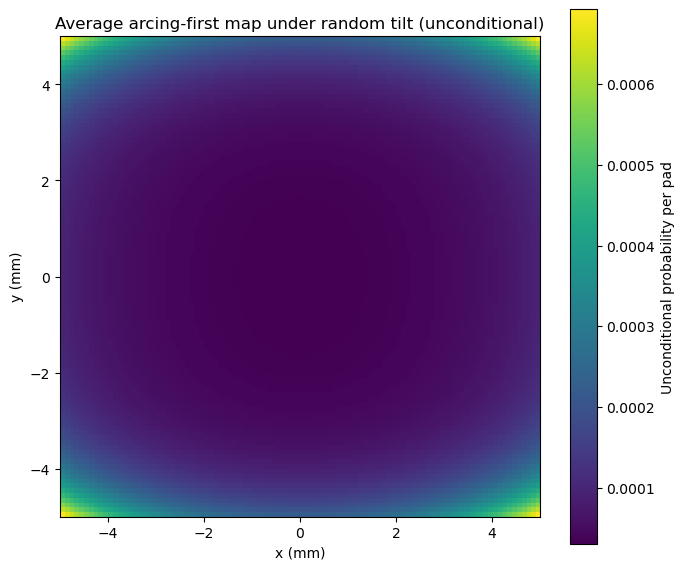

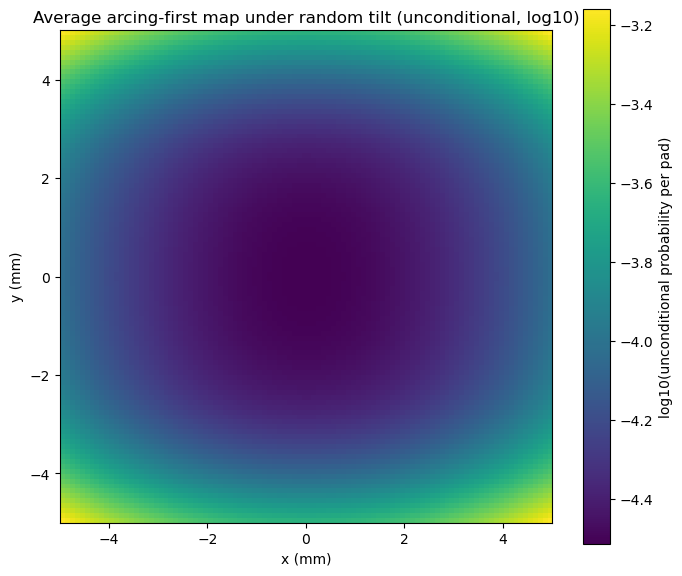

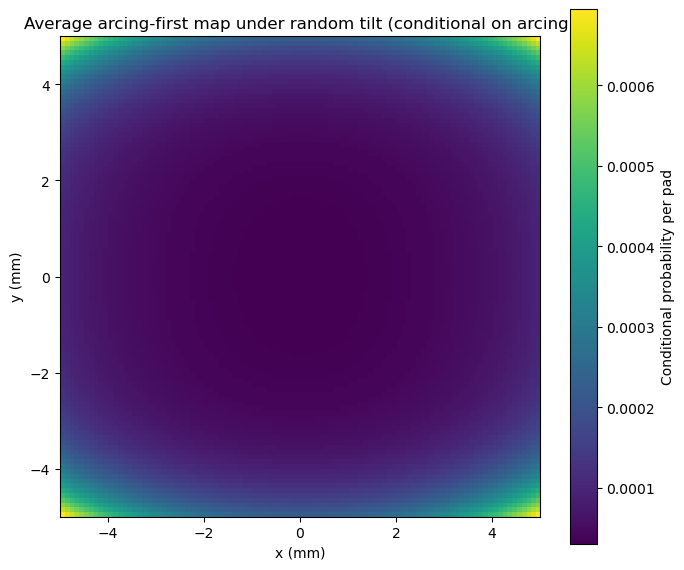

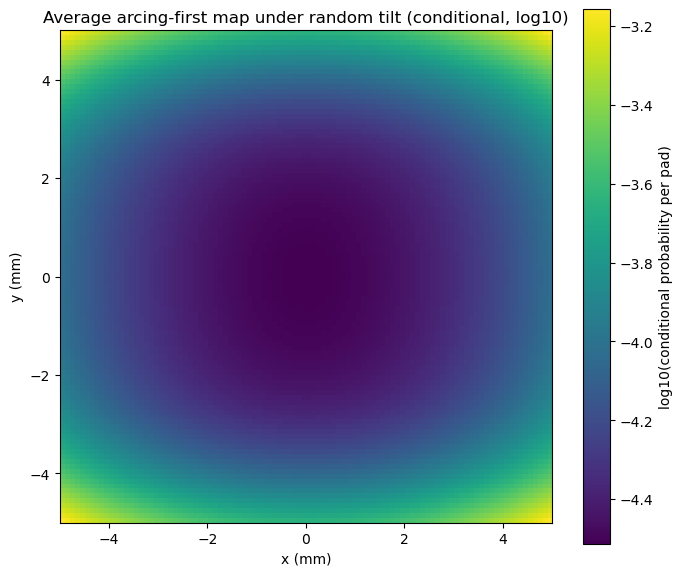

['arcing_first_event_random_tilt_notebook_analytical_unconditional_linear.png',
 'arcing_first_event_random_tilt_notebook_analytical_unconditional_log10.png',
 'arcing_first_event_random_tilt_notebook_analytical_conditional_linear.png',
 'arcing_first_event_random_tilt_notebook_analytical_conditional_log10.png']

In [65]:
plot_map_pair(
    uncond=avg_result.avg_prob_uncond,
    cond=avg_result.avg_prob_cond,
    grid=avg_result.grid,
    params=params,
    prefix='arcing_first_event_random_tilt_notebook_analytical',
    title_prefix='Average arcing-first map under random tilt',
)


## Monte Carlo validation

This samples random top/bottom dishing and random tilt angles directly.


In [8]:
t0 = time.time()
mc_result = monte_carlo_arcing_map(params, verbose=True)
t1 = time.time()
print(f'Monte Carlo finished in {t1 - t0:.2f}s')
print(summarize_mc_result(mc_result, params))


[MC] 10000/2000000 trials done, elapsed=1.67s
[MC] 20000/2000000 trials done, elapsed=3.30s
[MC] 30000/2000000 trials done, elapsed=4.94s
[MC] 40000/2000000 trials done, elapsed=6.58s
[MC] 50000/2000000 trials done, elapsed=8.22s
[MC] 60000/2000000 trials done, elapsed=9.85s
[MC] 70000/2000000 trials done, elapsed=11.49s
[MC] 80000/2000000 trials done, elapsed=13.12s
[MC] 90000/2000000 trials done, elapsed=14.76s
[MC] 100000/2000000 trials done, elapsed=16.39s
[MC] 110000/2000000 trials done, elapsed=18.03s
[MC] 120000/2000000 trials done, elapsed=19.66s
[MC] 130000/2000000 trials done, elapsed=21.30s
[MC] 140000/2000000 trials done, elapsed=22.94s
[MC] 150000/2000000 trials done, elapsed=24.58s
[MC] 160000/2000000 trials done, elapsed=26.21s
[MC] 170000/2000000 trials done, elapsed=27.85s
[MC] 180000/2000000 trials done, elapsed=29.49s
[MC] 190000/2000000 trials done, elapsed=31.13s
[MC] 200000/2000000 trials done, elapsed=32.76s
[MC] 210000/2000000 trials done, elapsed=34.40s
[MC] 22

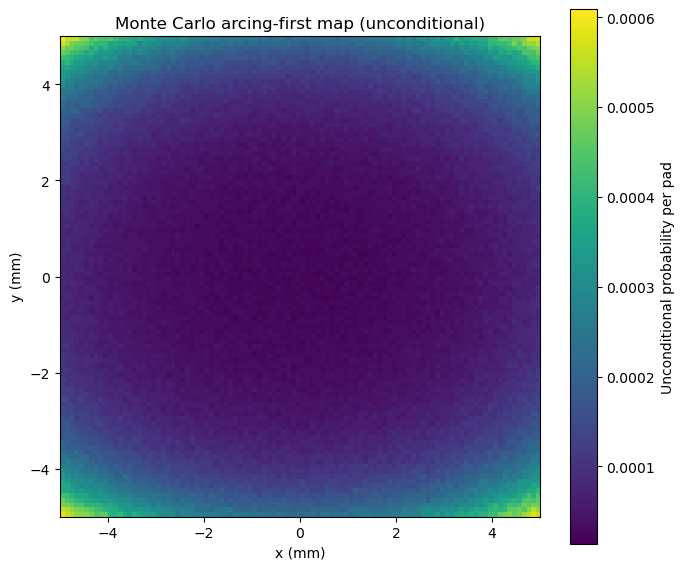

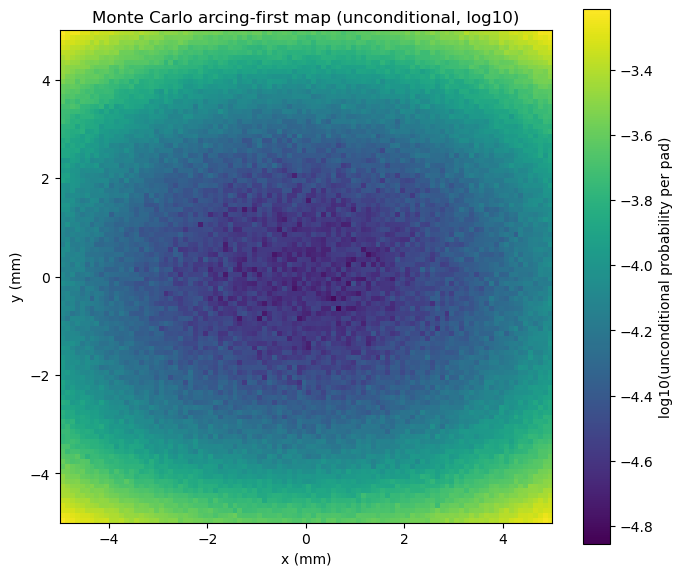

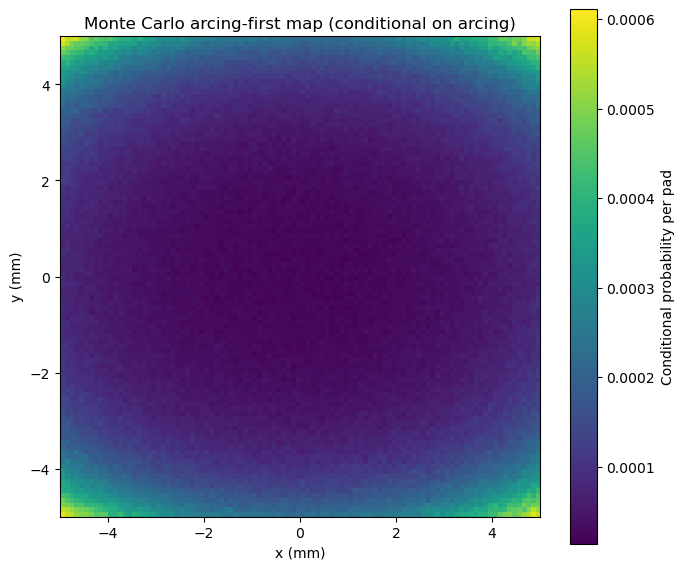

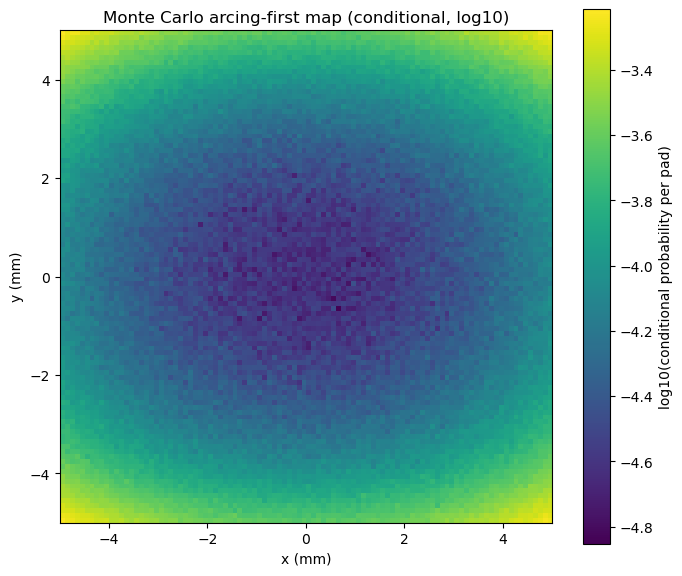

['arcing_first_event_random_tilt_notebook_mc_unconditional_linear.png',
 'arcing_first_event_random_tilt_notebook_mc_unconditional_log10.png',
 'arcing_first_event_random_tilt_notebook_mc_conditional_linear.png',
 'arcing_first_event_random_tilt_notebook_mc_conditional_log10.png']

In [9]:
plot_map_pair(
    uncond=mc_result.prob_uncond,
    cond=mc_result.prob_cond,
    grid=mc_result.grid,
    params=params,
    prefix='arcing_first_event_random_tilt_notebook_mc',
    title_prefix='Monte Carlo arcing-first map',
)


## Analytical vs Monte Carlo comparison


In [ ]:
print(compare_analytical_and_mc(avg_result, mc_result))
